# Task 10: Camera Calibration and Lens Undistortion

## Objective

The objective of this task is to calibrate a camera using multiple checkerboard images, estimate the camera intrinsic parameters and distortion coefficients, and use them to remove lens distortion from an image.

In [33]:
#import the req libs

import cv2
import numpy as np
import glob
import os
from google.colab.patches import cv2_imshow

In [34]:
# Checkerboard size (9 x 6 internal corners)

CHECKERBOARD = (8, 5)

criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

objp = np.zeros(
    (CHECKERBOARD[0] * CHECKERBOARD[1], 3),
    np.float32
)

objp[:, :2] = np.mgrid[
    0:CHECKERBOARD[0],
    0:CHECKERBOARD[1]
].T.reshape(-1, 2)

objpoints = []

imgpoints = []

In [35]:
images = glob.glob("/content/*.jpeg")
print("Number of Images Found:", len(images))

Number of Images Found: 15


In [36]:
valid_images = 0
discarded_images = 0

for image_file in images:

    image = cv2.imread(image_file)

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    ret, corners = cv2.findChessboardCorners(
        gray,
        CHECKERBOARD,
        None
    )

    if ret:

        valid_images += 1

        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(
            gray,
            corners,
            (11,11),
            (-1,-1),
            criteria
        )

        imgpoints.append(corners2)

    else:

        discarded_images += 1


print("Valid Images     :", valid_images)

print("Discarded Images :", discarded_images)

Valid Images     : 15
Discarded Images : 0


## Discarded Images

All 15 checkerboard images were successfully detected by the corner detection algorithm. Therefore, no images had to be discarded during the calibration process.

## Camera Calibration

The detected checkerboard corners are used to estimate the intrinsic camera parameters and distortion coefficients using `cv2.calibrateCamera()`.

In [37]:
# Perform camera calibration

ret, camera_matrix, distortion_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    gray.shape[::-1],
    None,
    None
)

print("Camera Calibration Successful!")

Camera Calibration Successful!


## Camera Intrinsic Parameters

The intrinsic camera matrix contains the focal lengths (`fx`, `fy`) and the optical center (`cx`, `cy`).

The distortion coefficients represent the lens distortion estimated during calibration.

In [38]:
print("=" * 60)

print("Camera Matrix")
print(camera_matrix)

print("=" * 60)

print("Distortion Coefficients")
print(distortion_coeffs.ravel())

print("=" * 60)

fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]

cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

print(f"Focal Length fx : {fx:.4f}")
print(f"Focal Length fy : {fy:.4f}")

print()

print(f"Principal Point cx : {cx:.4f}")
print(f"Principal Point cy : {cy:.4f}")

Camera Matrix
[[1.19278083e+03 0.00000000e+00 7.92938176e+02]
 [0.00000000e+00 1.19027306e+03 5.82998788e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients
[ 1.44896607e-01 -8.82594402e-01 -4.53659041e-03 -1.03461934e-04
  1.46655295e+00]
Focal Length fx : 1192.7808
Focal Length fy : 1190.2731

Principal Point cx : 792.9382
Principal Point cy : 582.9988


In [40]:
total_error = 0

for i in range(len(objpoints)):

    projected_points, _ = cv2.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        distortion_coeffs
    )

    # Convert both arrays to the same shape and type
    pt1 = imgpoints[i].astype(np.float32).reshape(-1, 2)
    pt2 = projected_points.astype(np.float32).reshape(-1, 2)

    error = cv2.norm(
        pt1,
        pt2,
        cv2.NORM_L2
    ) / len(pt2)

    total_error += error

mean_error = total_error / len(objpoints)

print("=" * 60)
print(f"Mean Reprojection Error : {mean_error:.6f}")
print("=" * 60)

Mean Reprojection Error : 0.059143


## Lens Undistortion

The computed camera parameters are used to remove lens distortion from an image containing straight edges.

In [50]:
test_img = cv2.imread("/content/d4.jpeg")

h, w = test_img.shape[:2]

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    distortion_coeffs,
    (w, h),
    1,
    (w, h)
)

undistorted = cv2.undistort(
    test_img,
    camera_matrix,
    distortion_coeffs,
    None,
    new_camera_matrix
)

x, y, rw, rh = roi

undistorted = undistorted[y:y+rh, x:x+rw]

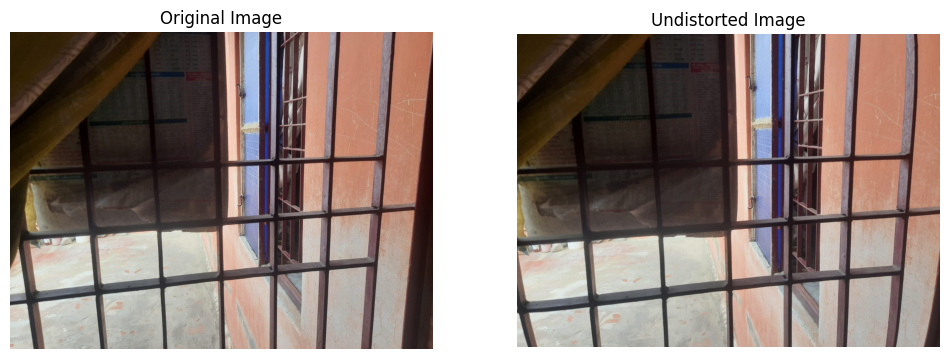

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.title("Undistorted Image")
plt.axis("off")

plt.show()

## Observation

The camera was successfully calibrated using the checkerboard images, and the estimated camera parameters were used to undistort the test image. The original and undistorted images appear very similar because the camera used for capturing the images has only minimal lens distortion. Small geometric corrections were applied near the image boundaries, indicating that the calibration process worked correctly.